This time, we focus on a small set of papers from 2021-- and draw the figures needed for the paper.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [3]:
CAMBRIDGE_COLORS = {
    # Core palette
    "cambridge_blue": "#8EE8D8",
    "cambridge_light_blue": "#D1F9F1",
    "cambridge_warm_blue": "#00BDB6",
    "cambridge_dark_blue": "#133844",
    # Crest series
    "light_crest": "#FFE2C8",
    "warm_crest": "#FFC392",
    "crest": "#FD8153",
    "dark_crest": "#DD3025",
    # Cherry series
    "light_cherry": "#F2CAD8",
    "warm_cherry": "#E18AAC",
    "cherry": "#CD3572",
    "dark_cherry": "#911449",
    # Purple series
    "light_purple": "#F2ECF8",
    "warm_purple": "#D1B7EB",
    "purple": "#A368DF",
    "dark_purple": "#681FB1",
    # Indigo series
    "light_indigo": "#EBEDFB",
    "warm_indigo": "#B0B9F1",
    "indigo": "#5366E0",
    "dark_indigo": "#29347A",
    # Green series
    "light_green": "#DFF2EA",
    "warm_green": "#AFDFCB",
    "green": "#4DB78C",
    "dark_green": "#13553A",
    # Greyscale
    "white": "#FFFFFF",
    "slate_1": "#ECEEF1",
    "slate_2": "#B5BDC8",
    "slate_3": "#546072",
    "slate_4": "#232830",
    # Heritage & special
    "heritage_blue": "#85B09A",
    "judge_yellow": "#ffb81c",
}

# Use TeX fonts with Times New Roman
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{mathptmx}",  # Times font for math and text
        "font.family": "serif",
        "font.serif": ["Times"],
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "font.size": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

In [4]:
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./outputs/2026-02-12-figures-for-paper")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [5]:
df = pd.read_csv(DATA_DIR / "interventions_dataset.csv")

## Tokenizer Fertility vs Common Crawl Percentage

In [8]:
# Load language resourceness data
lang_df = pd.read_csv(DATA_DIR / "tokenizer_fertility" / "language_resourceness.csv")

# Load tokenizer fertility data for each model
fertility_dir = DATA_DIR / "tokenizer_fertility"
model_files = [
    f for f in fertility_dir.glob("*.csv") if f.name != "language_resourceness.csv"
]

# Create a combined dataframe with all models
fertility_dfs = []
for model_file in model_files:
    model_name = model_file.stem.replace("___", "/")
    model_df = pd.read_csv(model_file)
    model_df["model"] = model_name
    fertility_dfs.append(model_df)

fertility_df = pd.concat(fertility_dfs, ignore_index=True)

# Merge with language data
merged_df = fertility_df.merge(lang_df, on="subset", how="left")

# Remove languages not in Common Crawl
merged_df = merged_df[merged_df["commoncrawl_percentage"] > 0]

print(f"Models: {merged_df['model'].unique()}")
print(f"Languages after filtering: {merged_df['subset'].nunique()}")
print(f"Language families: {merged_df['lang_family'].nunique()}")
merged_df.head()

Models: ['openai/gpt-oss-120b' 'swiss-ai/Apertus-8B-2509'
 'meta-llama/Llama-3.1-8B' 'Qwen/Qwen3-8B-Base' 'google/gemma-3-12b-pt']
Languages after filtering: 148
Language families: 20


,subset,tpw,tpb,tt,tw,tb,model,commoncrawl_percentage,lang2tax,language_name,lang_family
2,acm_Arab,1.602173,0.180853,35541,22183,196519,openai/gpt-oss-120b,0.6630,0,Mesopotamian Arabic,Afro-Asiatic
3,acq_Arab,1.552604,0.178903,35477,22850,198303,openai/gpt-oss-120b,0.6630,5,Ta'izzi-Adeni Arabic,Afro-Asiatic
4,aeb_Arab,1.590116,0.188126,36455,22926,193780,openai/gpt-oss-120b,0.6630,0,Tunisian Arabic,Afro-Asiatic
5,afr_Latn,1.367112,0.270770,36398,26624,134424,openai/gpt-oss-120b,0.0095,3,Afrikaans,Indo-European
6,als_Latn,1.692683,0.308082,46801,27649,151911,openai/gpt-oss-120b,0.0502,1,Tosk Albanian,Indo-European


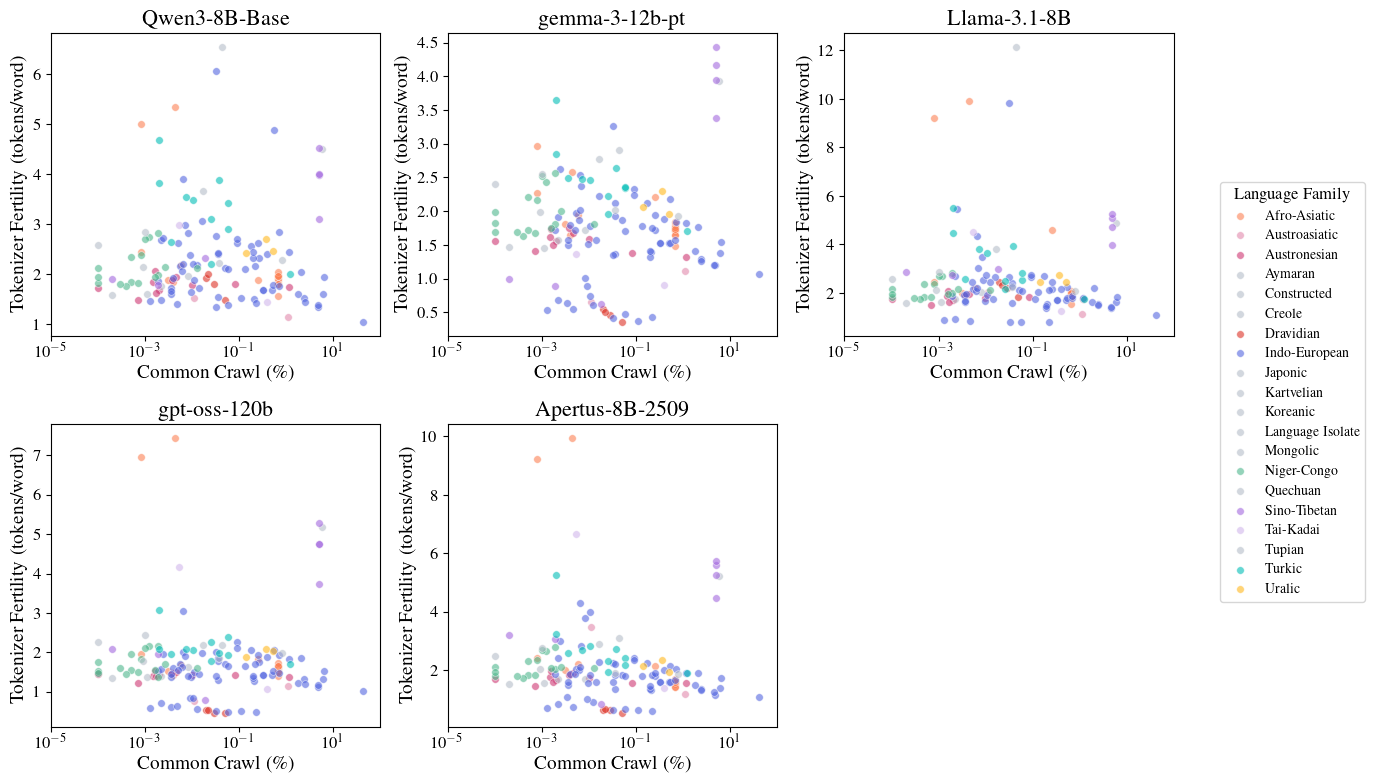

In [9]:
# Get unique models and language families
models = sorted(merged_df["model"].unique())
lang_families = sorted(merged_df["lang_family"].dropna().unique())

# Create a color palette for language families
family_colors = {
    "Indo-European": CAMBRIDGE_COLORS["indigo"],
    "Afro-Asiatic": CAMBRIDGE_COLORS["crest"],
    "Niger-Congo": CAMBRIDGE_COLORS["green"],
    "Austronesian": CAMBRIDGE_COLORS["cherry"],
    "Sino-Tibetan": CAMBRIDGE_COLORS["purple"],
    "Turkic": CAMBRIDGE_COLORS["cambridge_warm_blue"],
    "Uralic": CAMBRIDGE_COLORS["judge_yellow"],
    "Dravidian": CAMBRIDGE_COLORS["dark_crest"],
    "Austroasiatic": CAMBRIDGE_COLORS["warm_cherry"],
    "Tai-Kadai": CAMBRIDGE_COLORS["warm_purple"],
}
# Default color for other families
default_color = CAMBRIDGE_COLORS["slate_2"]

# Create faceted scatter plot
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), squeeze=False)
axes = axes.flatten()

for idx, model in enumerate(models):
    ax = axes[idx]
    model_data = merged_df[merged_df["model"] == model]

    # Plot each language family
    for family in lang_families:
        family_data = model_data[model_data["lang_family"] == family]
        if len(family_data) > 0:
            color = family_colors.get(family, default_color)
            ax.scatter(
                family_data["commoncrawl_percentage"],
                family_data["tpw"],
                c=color,
                label=family if idx == 0 else "",
                alpha=0.6,
                s=30,
                edgecolors="white",
                linewidths=0.5,
            )

    ax.set_xlabel("Common Crawl (\%)")
    ax.set_ylabel("Tokenizer Fertility (tokens/word)")
    ax.set_title(model.split("/")[-1])
    ax.set_xscale("log")
    ax.set_xlim(1e-5, 100)

# Hide empty subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

# Add legend to the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.15, 0.5),
    title="Language Family",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tokenizer_fertility_vs_cc.pdf", bbox_inches="tight", dpi=300)
plt.show()